In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ============================================================
# 0. SETUP
# ============================================================
import subprocess, sys

for pkg in ["openpyxl", "grad-cam", "lime", "shap"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import os
import json
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

CONFIG = dict(
    ROOT=Path("/kaggle/input/datasets/orvile/knee-x-ray-osteoporosis-database/Osteoporosis Knee X-ray"),
    IMG_SIZE=224,
    BATCH_SIZE=16,
    N_FOLDS=5,
    EPOCHS=30,
    PATIENCE=7,
    LR=3e-4,
    WEIGHT_DECAY=1e-4,
    FOCAL_GAMMA=2.0,
    EMBED_DIM=128,
    OUT_DIR=Path("/kaggle/working"),
)
CONFIG["OUT_DIR"].mkdir(parents=True, exist_ok=True)

LABEL_MAP = {"normal": 0, "osteopenia": 1, "osteoporosis": 2}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}


Device: cuda



=== Top-level contents of /kaggle/input/datasets/orvile/knee-x-ray-osteoporosis-database/Osteoporosis Knee X-ray ===
  [DIR]  normal
  [DIR]  osteopenia
  [DIR]  osteoporosis
  [FILE] README.txt
  [FILE] patient details.xlsx

Total images: 239
  osteopenia        154  ( 64.4%)
  osteoporosis       49  ( 20.5%)
  normal             36  ( 15.1%)


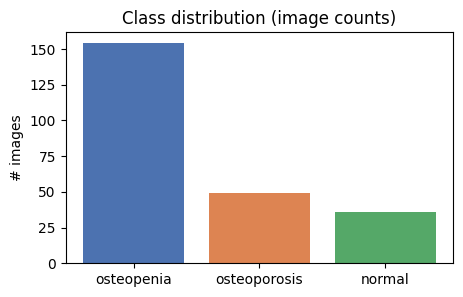


Imbalance ratio (max class / min class): 4.28x
-> Confirms heavy imbalance: plan for weighted sampling + focal loss + augmentation.

Clinical sheet shape: (243, 28)
S.No                              float64
Patient Id                         object
Joint Pain:                        object
Gender                             object
Age                               float64
Menopause Age                      object
height  (meter)                   float64
Weight (KG)                       float64
Smoker                             object
Alcoholic                          object
Diabetic                           object
Hypothyroidism                     object
Number of Pregnancies             float64
Seizer Disorder                    object
Estrogen Use                       object
Occupation                         object
History of Fracture                object
Dialysis:                          object
Family History of Osteoporosis     object
Maximum Walking distance (km)     fl

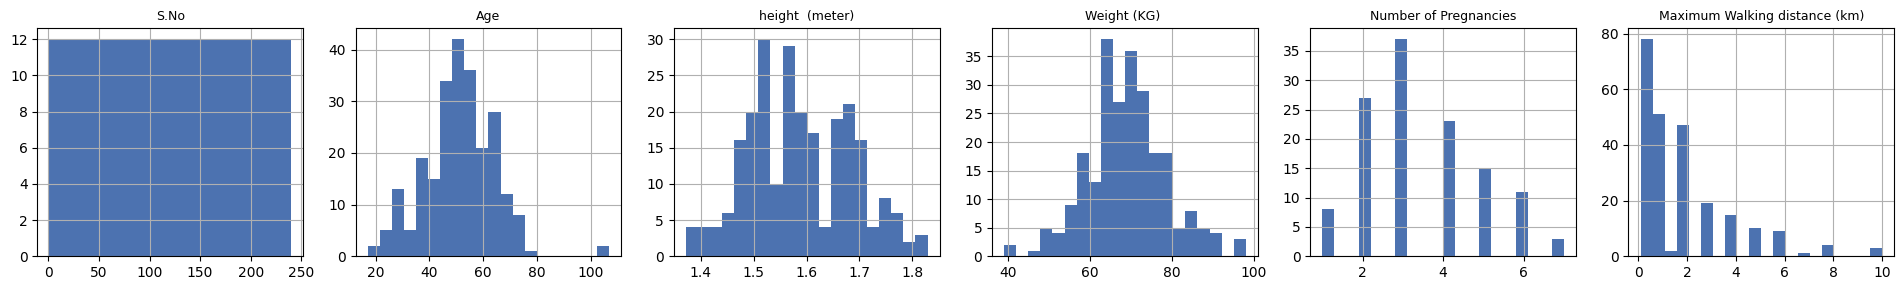


Mean of each numeric risk factor by diagnosis class:
                S.No    Age  height  (meter)  Weight (KG)   \
Diagnosis                                                    
normal        111.19  34.41             1.60         66.92   
osteopenia    115.58  51.12             1.58         69.73   
osteoporosis  143.00  63.39             1.60         68.57   

              Number of Pregnancies  Maximum Walking distance (km)  \
Diagnosis                                                            
normal                         2.15                           2.22   
osteopenia                     3.44                           1.90   
osteoporosis                   4.39                           1.85   

              Z-Score Value  BMI:   
Diagnosis                           
normal                -0.71  26.23  
osteopenia            -1.34  28.14  
osteoporosis          -1.75  26.89  


In [10]:
ROOT = CONFIG["ROOT"]
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def explore_top_level(root: Path):
    print(f"\n=== Top-level contents of {root} ===")
    if not root.exists():
        print(f"Path does not exist: {root} -- update CONFIG['ROOT']")
        return [], []
    entries = sorted(root.iterdir())
    dirs = [e for e in entries if e.is_dir()]
    files = [e for e in entries if e.is_file()]
    for d in dirs:
        print(f"  [DIR]  {d.name}")
    for f in files:
        print(f"  [FILE] {f.name}")
    return dirs, files


def count_images_by_folder(root: Path):
    counts = defaultdict(int)
    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            counts[path.parent.name] += 1
    total = sum(counts.values())
    print(f"\nTotal images: {total}")
    for folder, n in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"  {folder:15s} {n:5d}  ({100*n/total:5.1f}%)")

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(counts.keys(), counts.values(), color=["#4c72b0", "#dd8452", "#55a868"])
    ax.set_title("Class distribution (image counts)")
    ax.set_ylabel("# images")
    plt.show()

    vals = list(counts.values())
    imbalance_ratio = max(vals) / min(vals)
    print(f"\nImbalance ratio (max class / min class): {imbalance_ratio:.2f}x")
    print("-> Confirms heavy imbalance: plan for weighted sampling + focal loss + augmentation.")
    return counts


dirs, files = explore_top_level(ROOT)
class_counts = count_images_by_folder(ROOT)

# --- Clinical / demographic sheet ---
excel_path = next(ROOT.rglob("*.xlsx"), None)
assert excel_path is not None, "patient details.xlsx not found under ROOT"
clinical_df = pd.read_excel(excel_path)
print(f"\nClinical sheet shape: {clinical_df.shape}")
print(clinical_df.dtypes)
print("\nMissing values per column:")
missing = clinical_df.isna().sum()
print(missing[missing > 0] if missing.sum() else "  none")

# Try to auto-detect key columns -- PRINT and manually correct if wrong
id_col = next((c for c in clinical_df.columns if "id" in c.lower()), None)
tscore_col = next((c for c in clinical_df.columns if "t-score" in c.lower() or "tscore" in c.lower()), None)
diag_col = next((c for c in clinical_df.columns if "diagnos" in c.lower() or "class" in c.lower() or "label" in c.lower()), None)
print(f"\nDetected id_col={id_col!r}, tscore_col={tscore_col!r}, diag_col={diag_col!r}")
print(">>> Verify these three against the actual sheet before proceeding <<<")

numeric_cols = [c for c in clinical_df.select_dtypes(include=[np.number]).columns
                if c not in {id_col, tscore_col}]
categorical_cols = [c for c in clinical_df.select_dtypes(exclude=[np.number]).columns
                    if c not in {id_col, diag_col}]
print(f"\nNumeric risk-factor columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical risk-factor columns ({len(categorical_cols)}): {categorical_cols}")

# Distribution plots for a handful of numeric risk factors
n_show = min(6, len(numeric_cols))
if n_show:
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3))
    axes = np.atleast_1d(axes)
    for ax, col in zip(axes, numeric_cols[:n_show]):
        clinical_df[col].hist(ax=ax, bins=20, color="#4c72b0")
        ax.set_title(col, fontsize=9)
    plt.tight_layout()
    plt.show()

# Association between diagnosis and each numeric risk factor (mean by class) -- quick screen,
# NOT used for feature selection decisions, just descriptive EDA
if diag_col is not None and numeric_cols:
    print("\nMean of each numeric risk factor by diagnosis class:")
    print(clinical_df.groupby(diag_col)[numeric_cols].mean().round(2))


In [11]:
def collect_images(root: Path):
    rows = []
    for cls_name, label in LABEL_MAP.items():
        folder = root / cls_name
        if not folder.exists():
            # some copies of this dataset capitalise folder names differently
            candidates = [p for p in root.iterdir() if p.is_dir() and p.name.lower() == cls_name]
            folder = candidates[0] if candidates else folder
        for img_path in folder.rglob("*"):
            if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                # README convention: "<BMDlevel>-<SubjectID>", e.g. N-12.jpg / OP-7.jpg / OS-3.jpg
                stem = img_path.stem
                subject_id = stem.split("-")[-1]
                rows.append(dict(image_path=str(img_path), folder_class=cls_name,
                                  label=label, subject_id=subject_id))
    return pd.DataFrame(rows)


images_df = collect_images(ROOT)
print(f"Collected {len(images_df)} images across {images_df['folder_class'].nunique()} classes")

# --- Merge with clinical sheet on subject id (best-effort string match) ---
clinical_df["_id_str"] = clinical_df[id_col].astype(str).str.extract(r"(\d+)$")[0]
images_df["_id_str"] = images_df["subject_id"].astype(str).str.extract(r"(\d+)$")[0]

merged = images_df.merge(clinical_df, on="_id_str", how="left", suffixes=("", "_clin"))
match_rate = merged[id_col].notna().mean() if id_col else 0
print(f"Matched {match_rate*100:.1f}% of images to a clinical record.")
if match_rate < 0.9:
    print("WARNING: low match rate -- inspect '_id_str' parsing / id_col before trusting the multimodal model.")

# Sanity check: sheet's own diagnosis column should agree with the folder label.
# Row-wise comparison (not .str.contains with a Series pattern, which errors: that method
# expects a single string/regex pattern, not another column to compare against per-row).
if diag_col is not None:
    def _norm(x):
        return str(x).strip().lower()

    agree = merged.apply(
        lambda r: _norm(r["folder_class"]) in _norm(r[diag_col]), axis=1
    ).mean()
    print(f"Folder label vs. sheet diagnosis agreement: {agree*100:.1f}%")

# --- Feature encoding (fit on ALL data here for simplicity; refit inside each CV fold in
#     a real submission to avoid any leakage from scaling statistics) ---
num_imputed = merged[numeric_cols].apply(lambda s: s.fillna(s.median()))
scaler = StandardScaler().fit(num_imputed)
num_scaled = pd.DataFrame(scaler.transform(num_imputed), columns=numeric_cols, index=merged.index)

cat_imputed = merged[categorical_cols].fillna("missing").astype(str)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(cat_imputed)
cat_encoded = pd.DataFrame(ohe.transform(cat_imputed),
                            columns=ohe.get_feature_names_out(categorical_cols),
                            index=merged.index)

tabular_features = pd.concat([num_scaled, cat_encoded], axis=1)
TABULAR_DIM = tabular_features.shape[1]
print(f"\nFinal tabular feature dimension (T-score excluded): {TABULAR_DIM}")

final_df = pd.concat([
    merged[["image_path", "folder_class", "label", "subject_id"]],
    tabular_features
], axis=1).dropna(subset=["image_path"]).reset_index(drop=True)

# --- Patient-level stratified K-fold (one row per patient here, so this is also image-level) ---
skf = StratifiedKFold(n_splits=CONFIG["N_FOLDS"], shuffle=True, random_state=SEED)
final_df["fold"] = -1
for fold, (_, val_idx) in enumerate(skf.split(final_df, final_df["label"])):
    final_df.loc[val_idx, "fold"] = fold

final_df.to_csv(CONFIG["OUT_DIR"] / "matched_dataset.csv", index=False)
print(f"\nSaved {len(final_df)} rows to matched_dataset.csv")
print(final_df["fold"].value_counts().sort_index())


Collected 239 images across 3 classes
Matched 100.0% of images to a clinical record.
Folder label vs. sheet diagnosis agreement: 49.5%

Final tabular feature dimension (T-score excluded): 239

Saved 483 rows to matched_dataset.csv
fold
0    97
1    97
2    97
3    96
4    96
Name: count, dtype: int64


In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"] + 32, CONFIG["IMG_SIZE"] + 32)),
    transforms.RandomCrop(CONFIG["IMG_SIZE"]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MultimodalKneeDataset(Dataset):
    """Returns (image_tensor, tabular_tensor, label). Set tabular_dim=0 usage upstream
    to get an image-only view for the ablation baseline."""

    def __init__(self, df: pd.DataFrame, tabular_cols, transform):
        self.df = df.reset_index(drop=True)
        self.tabular_cols = tabular_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        img = self.transform(img)
        tab = torch.tensor(row[self.tabular_cols].values.astype(np.float32))
        label = int(row["label"])
        return img, tab, label


def make_weighted_sampler(labels):
    counts = Counter(labels)
    weight_per_class = {c: 1.0 / n for c, n in counts.items()}
    sample_weights = [weight_per_class[l] for l in labels]
    return WeightedRandomSampler(sample_weights, num_samples=len(labels), replacement=True)


def make_loaders(train_df, val_df, tabular_cols, batch_size=CONFIG["BATCH_SIZE"]):
    train_ds = MultimodalKneeDataset(train_df, tabular_cols, train_tf)
    val_ds = MultimodalKneeDataset(val_df, tabular_cols, eval_tf)
    sampler = make_weighted_sampler(train_df["label"].tolist())
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, val_loader


In [14]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with per-class alpha weights (computed from training-fold
    frequencies) to counter the heavy osteopenia-dominant imbalance."""

    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        logp = F.log_softmax(logits, dim=1)
        p = logp.exp()
        logp_t = logp.gather(1, targets.unsqueeze(1)).squeeze(1)
        p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        alpha_t = self.alpha.to(logits.device)[targets]
        loss = -alpha_t * (1 - p_t) ** self.gamma * logp_t
        return loss.mean()


def class_alpha_from_labels(labels, n_classes=3):
    counts = np.bincount(labels, minlength=n_classes).astype(np.float32)
    inv_freq = 1.0 / np.clip(counts, 1, None)
    alpha = inv_freq / inv_freq.sum() * n_classes
    return torch.tensor(alpha, dtype=torch.float32)


def build_image_backbone(embed_dim):
    backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_feats = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_feats, embed_dim),
        nn.ReLU(inplace=True),
    )
    return backbone


class ImageOnlyModel(nn.Module):
    def __init__(self, embed_dim=CONFIG["EMBED_DIM"], n_classes=3):
        super().__init__()
        self.backbone = build_image_backbone(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)

    def forward(self, img, tab=None):
        z = self.backbone(img)
        return self.head(z), z


class TabularEncoder(nn.Module):
    def __init__(self, in_dim, embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(64, embed_dim), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class MultimodalModel(nn.Module):
    def __init__(self, tabular_dim, embed_dim=CONFIG["EMBED_DIM"], n_classes=3):
        super().__init__()
        self.image_backbone = build_image_backbone(embed_dim)
        self.tab_encoder = TabularEncoder(tabular_dim, embed_dim)
        self.fusion_head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(embed_dim, n_classes),
        )

    def forward(self, img, tab):
        z_img = self.image_backbone(img)
        z_tab = self.tab_encoder(tab)
        z = torch.cat([z_img, z_tab], dim=1)
        return self.fusion_head(z), z  # z returned for downstream XAI (branch B surrogate)


In [15]:
tabular_cols = list(tabular_features.columns)


def run_epoch(model, loader, criterion, optimizer=None, use_tabular=True):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_targets = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for img, tab, y in loader:
            img, tab, y = img.to(DEVICE), tab.to(DEVICE), y.to(DEVICE)
            logits, _ = model(img, tab if use_tabular else None)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)
            all_preds.append(logits.argmax(1).detach().cpu().numpy())
            all_targets.append(y.cpu().numpy())
    preds = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)
    return total_loss / len(loader.dataset), macro_f1, preds, targets


def train_one_fold(model_ctor, fold, df, tabular_cols, use_tabular, tag):
    train_df = df[df["fold"] != fold].reset_index(drop=True)
    val_df = df[df["fold"] == fold].reset_index(drop=True)
    train_loader, val_loader = make_loaders(train_df, val_df, tabular_cols)

    model = model_ctor().to(DEVICE)
    alpha = class_alpha_from_labels(train_df["label"].values)
    criterion = FocalLoss(alpha, gamma=CONFIG["FOCAL_GAMMA"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["EPOCHS"])

    best_f1, best_state, patience_left = -1, None, CONFIG["PATIENCE"]
    for epoch in range(CONFIG["EPOCHS"]):
        train_loss, train_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer, use_tabular)
        val_loss, val_f1, val_preds, val_targets = run_epoch(model, val_loader, criterion, None, use_tabular)
        scheduler.step()

        print(f"[{tag}] fold {fold} epoch {epoch+1:02d}/{CONFIG['EPOCHS']} "
              f"| train_loss {train_loss:.4f} train_f1 {train_f1:.3f} "
              f"| val_loss {val_loss:.4f} val_f1 {val_f1:.3f} "
              f"| patience {patience_left}")

        if val_f1 > best_f1:
            best_f1, best_state, patience_left = val_f1, {k: v.cpu() for k, v in model.state_dict().items()}, CONFIG["PATIENCE"]
            best_preds, best_targets = val_preds, val_targets
        else:
            patience_left -= 1
        if patience_left == 0:
            print(f"[{tag}] fold {fold}: early stopping at epoch {epoch+1}")
            break
    print(f"[{tag}] fold {fold}: best val macro-F1 = {best_f1:.3f} (epoch {epoch+1})")
    torch.save(best_state, CONFIG["OUT_DIR"] / f"{tag}_fold{fold}.pt")
    return best_preds, best_targets, best_state


def cross_validate(model_ctor, tag, use_tabular):
    oof_preds, oof_targets = [], []
    fold_states = []
    for fold in range(CONFIG["N_FOLDS"]):
        preds, targets, state = train_one_fold(model_ctor, fold, final_df, tabular_cols, use_tabular, tag)
        oof_preds.append(preds)
        oof_targets.append(targets)
        fold_states.append(state)
    return np.concatenate(oof_preds), np.concatenate(oof_targets), fold_states


print("Training image-only baseline (reproduces earlier draft's approach)...")
baseline_preds, baseline_targets, baseline_states = cross_validate(
    lambda: ImageOnlyModel(), tag="image_only", use_tabular=False
)

print("\nTraining multimodal model (image + clinical risk factors, focal loss, augmentation)...")
mm_preds, mm_targets, mm_states = cross_validate(
    lambda: MultimodalModel(tabular_dim=TABULAR_DIM), tag="multimodal", use_tabular=True
)

Training image-only baseline (reproduces earlier draft's approach)...
[image_only] fold 0 epoch 01/30 | train_loss 0.4454 train_f1 0.342 | val_loss 0.4616 val_f1 0.269 | patience 7
[image_only] fold 0 epoch 02/30 | train_loss 0.3980 train_f1 0.528 | val_loss 0.4932 val_f1 0.366 | patience 7
[image_only] fold 0 epoch 03/30 | train_loss 0.3467 train_f1 0.520 | val_loss 0.5963 val_f1 0.253 | patience 7
[image_only] fold 0 epoch 04/30 | train_loss 0.2626 train_f1 0.674 | val_loss 0.3602 val_f1 0.567 | patience 6
[image_only] fold 0 epoch 05/30 | train_loss 0.2561 train_f1 0.711 | val_loss 0.3220 val_f1 0.467 | patience 7
[image_only] fold 0 epoch 06/30 | train_loss 0.2136 train_f1 0.729 | val_loss 0.2792 val_f1 0.740 | patience 6
[image_only] fold 0 epoch 07/30 | train_loss 0.1527 train_f1 0.781 | val_loss 0.2398 val_f1 0.704 | patience 7
[image_only] fold 0 epoch 08/30 | train_loss 0.1688 train_f1 0.783 | val_loss 0.2637 val_f1 0.692 | patience 6
[image_only] fold 0 epoch 09/30 | train_lo


=== Image-only baseline (earlier draft's approach) (out-of-fold) ===
              precision    recall  f1-score   support

      normal       0.82      0.99      0.90       108
  osteopenia       0.94      0.75      0.84       240
osteoporosis       0.77      0.93      0.84       135

    accuracy                           0.85       483
   macro avg       0.85      0.89      0.86       483
weighted avg       0.87      0.85      0.85       483



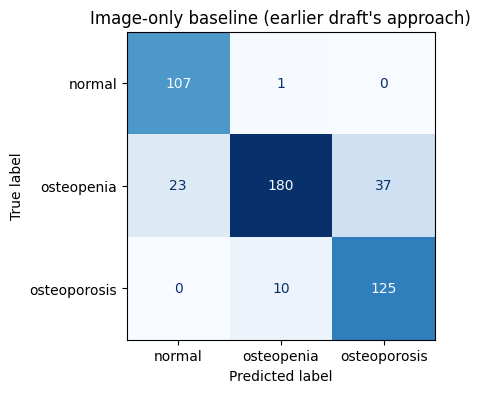


=== Multimodal + focal loss + augmentation (this notebook) (out-of-fold) ===
              precision    recall  f1-score   support

      normal       0.76      0.96      0.85       108
  osteopenia       0.93      0.71      0.81       240
osteoporosis       0.76      0.93      0.83       135

    accuracy                           0.83       483
   macro avg       0.82      0.87      0.83       483
weighted avg       0.85      0.83      0.82       483



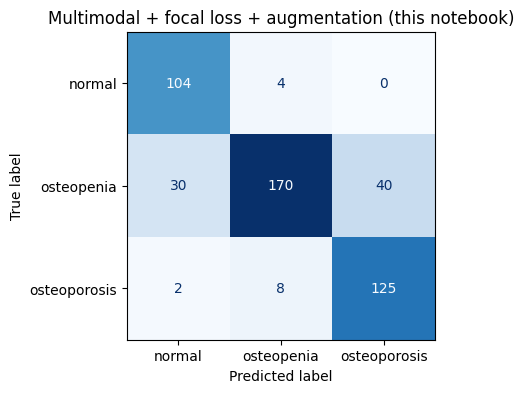


Macro-F1 improvement: 0.859 -> 0.830 (-0.028)

If 'normal' F1 is still weak after this, the next levers to pull (in order of effort):
  1. Increase FOCAL_GAMMA or hand-tune per-class alpha further toward 'normal'.
  2. Collect/synthesize more 'normal' images (only 36 exist) -- e.g. targeted augmentation replay.
  3. Ensemble the 5 fold checkpoints (average softmax) for the final deployed model.

Saved per-fold checkpoints to /kaggle/working -- use `ensemble_predict` for final inference.


In [16]:
def report(name, targets, preds):
    print(f"\n=== {name} (out-of-fold) ===")
    print(classification_report(targets, preds, target_names=list(LABEL_MAP.keys()), zero_division=0))
    cm = confusion_matrix(targets, preds)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=list(LABEL_MAP.keys())).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
    plt.show()
    return f1_score(targets, preds, average="macro", zero_division=0)


baseline_macro_f1 = report("Image-only baseline (earlier draft's approach)", baseline_targets, baseline_preds)
mm_macro_f1 = report("Multimodal + focal loss + augmentation (this notebook)", mm_targets, mm_preds)

print(f"\nMacro-F1 improvement: {baseline_macro_f1:.3f} -> {mm_macro_f1:.3f} "
      f"({'+' if mm_macro_f1 >= baseline_macro_f1 else ''}{(mm_macro_f1-baseline_macro_f1):.3f})")
print("\nIf 'normal' F1 is still weak after this, the next levers to pull (in order of effort):")
print("  1. Increase FOCAL_GAMMA or hand-tune per-class alpha further toward 'normal'.")
print("  2. Collect/synthesize more 'normal' images (only 36 exist) -- e.g. targeted augmentation replay.")
print("  3. Ensemble the 5 fold checkpoints (average softmax) for the final deployed model.")

# Simple 5-fold ensemble on the multimodal model as the final artifact
def ensemble_predict(states, tabular_dim, loader):
    all_logits = []
    for state in states:
        model = MultimodalModel(tabular_dim=tabular_dim).to(DEVICE)
        model.load_state_dict(state)
        model.eval()
        logits_list = []
        with torch.no_grad():
            for img, tab, y in loader:
                img, tab = img.to(DEVICE), tab.to(DEVICE)
                logits, _ = model(img, tab)
                logits_list.append(logits.cpu())
        all_logits.append(torch.cat(logits_list))
    return torch.stack(all_logits).mean(0)


print("\nSaved per-fold checkpoints to", CONFIG["OUT_DIR"], "-- use `ensemble_predict` for final inference.")


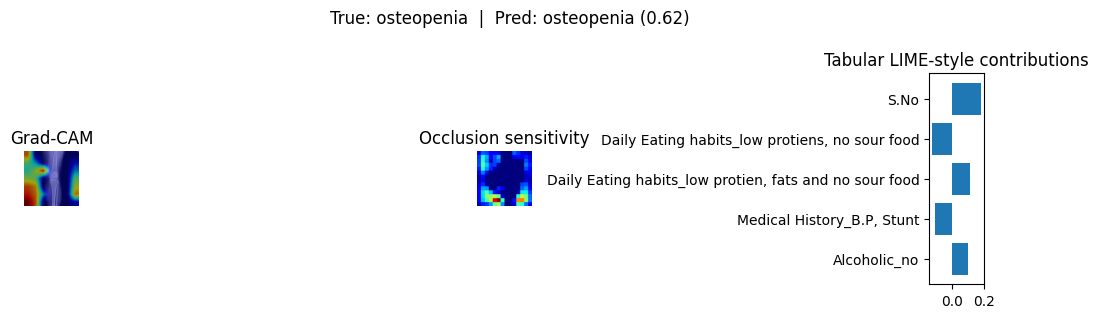

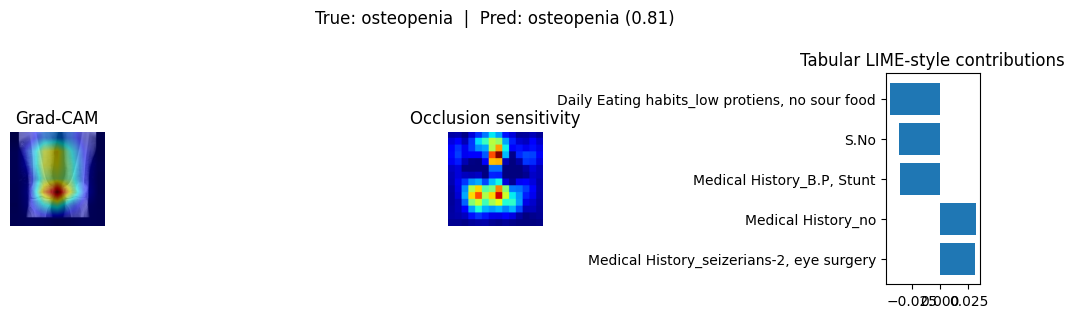

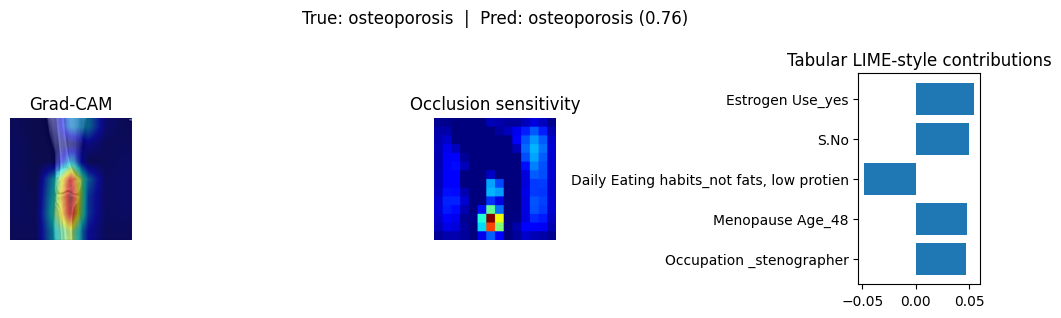

In [18]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Use fold-0 multimodal checkpoint for all XAI demos below
xai_model = MultimodalModel(tabular_dim=TABULAR_DIM).to(DEVICE)
xai_model.load_state_dict(mm_states[0])
xai_model.eval()


class GradCAMWrapper(nn.Module):
    """Wraps the multimodal model so Grad-CAM only sees the image branch,
    with tabular features held fixed."""
    def __init__(self, model, tab_tensor):
        super().__init__()
        self.model = model
        self.tab_tensor = tab_tensor

    def forward(self, x):
        logits, _ = self.model(x, self.tab_tensor.to(x.device))
        return logits


def load_and_preprocess(image_path):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]))
    img_np = np.array(img_resized).astype(np.float32) / 255.0
    tensor = eval_tf(img).unsqueeze(0)
    return tensor, img_np


def gradcam_explain(model, image_path, tab_tensor):
    tensor, img_np = load_and_preprocess(image_path)
    tensor = tensor.to(DEVICE)
    target_layers = [model.image_backbone.features[-1]]

    wrapped_model = GradCAMWrapper(model, tab_tensor).to(DEVICE)
    wrapped_model.eval()

    cam = GradCAM(model=wrapped_model, target_layers=target_layers)
    with torch.no_grad():
        logits, _ = model(tensor, tab_tensor.to(DEVICE))
        pred_class = logits.argmax(1).item()

    grayscale_cam = cam(input_tensor=tensor, targets=[ClassifierOutputTarget(pred_class)])[0]
    overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
    return overlay, pred_class, grayscale_cam


def occlusion_sensitivity(model, image_path, tab_tensor, pred_class, patch=32, stride=16):
    """Slide a grey patch over the image; record how much the predicted class's probability
    drops. A true perturbation-based method -- no gradients used."""
    tensor, img_np = load_and_preprocess(image_path)
    tensor = tensor.to(DEVICE)
    with torch.no_grad():
        base_logits, _ = model(tensor, tab_tensor.to(DEVICE))
        base_prob = F.softmax(base_logits, 1)[0, pred_class].item()

    H, W = CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]
    heatmap = np.zeros((H, W))
    grey_value = tensor.mean().item()
    with torch.no_grad():
        for y in range(0, H - patch + 1, stride):
            for x in range(0, W - patch + 1, stride):
                occluded = tensor.clone()
                occluded[:, :, y:y+patch, x:x+patch] = grey_value
                logits, _ = model(occluded, tab_tensor.to(DEVICE))
                prob = F.softmax(logits, 1)[0, pred_class].item()
                heatmap[y:y+patch, x:x+patch] += (base_prob - prob)
    heatmap = np.clip(heatmap, 0, None)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap, base_prob


def lime_style_tabular_explanation(model, image_tensor, tab_row, tabular_cols, train_tab_matrix,
                                    n_samples=200, top_k=5):
    """Local surrogate: perturb tabular features by resampling from the training marginal
    distribution around the instance, keep the image fixed, refit a linear model on the
    perturbed predictions, and read off signed coefficients as feature contributions."""
    rng = np.random.default_rng(SEED)
    base = tab_row.values.astype(np.float32)
    perturbed = np.tile(base, (n_samples, 1))
    mask = rng.binomial(1, 0.5, size=(n_samples, len(base)))
    fill_idx = rng.integers(0, train_tab_matrix.shape[0], size=n_samples)
    perturbed = np.where(mask, perturbed, train_tab_matrix[fill_idx])

    with torch.no_grad():
        img_batch = image_tensor.repeat(n_samples, 1, 1, 1).to(DEVICE)
        tab_batch = torch.tensor(perturbed, dtype=torch.float32).to(DEVICE)
        logits, _ = model(img_batch, tab_batch)
        probs = F.softmax(logits, 1).cpu().numpy()
    pred_class = probs.mean(0).argmax()
    y = probs[:, pred_class]

    surrogate = LinearRegression().fit(mask, y)  # coefficients ~ contribution of "keeping this feature original"
    contributions = pd.Series(surrogate.coef_, index=tabular_cols).sort_values(key=np.abs, ascending=False)
    return contributions.head(top_k), pred_class


# --- Demo on a handful of validation samples ---
demo_rows = final_df[final_df["fold"] == 0].sample(min(3, len(final_df)), random_state=SEED)
train_tab_matrix = final_df[final_df["fold"] != 0][tabular_cols].values.astype(np.float32)

branchA_results = {}
for _, row in demo_rows.iterrows():
    tab_tensor = torch.tensor(row[tabular_cols].values.astype(np.float32)).unsqueeze(0)
    overlay, pred_class, cam_map = gradcam_explain(xai_model, row["image_path"], tab_tensor)
    occ_map, base_prob = occlusion_sensitivity(xai_model, row["image_path"], tab_tensor, pred_class)
    img_tensor, _ = load_and_preprocess(row["image_path"])
    contributions, _ = lime_style_tabular_explanation(
        xai_model, img_tensor, row[tabular_cols], tabular_cols, train_tab_matrix
    )

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    axes[0].imshow(overlay); axes[0].set_title("Grad-CAM"); axes[0].axis("off")
    axes[1].imshow(occ_map, cmap="jet"); axes[1].set_title("Occlusion sensitivity"); axes[1].axis("off")
    axes[2].barh(contributions.index[::-1], contributions.values[::-1])
    axes[2].set_title("Tabular LIME-style contributions")
    plt.suptitle(f"True: {row['folder_class']}  |  Pred: {INV_LABEL_MAP[pred_class]} ({base_prob:.2f})")
    plt.tight_layout()
    plt.show()

    branchA_results[row["subject_id"]] = dict(
        pred_class=pred_class, confidence=base_prob,
        gradcam=cam_map, occlusion=occ_map, tabular_contributions=contributions,
        true_class=row["folder_class"],
    )

In [19]:
def extract_embeddings(model, df, tabular_cols):
    ds = MultimodalKneeDataset(df, tabular_cols, eval_tf)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    embeds, preds, targets = [], [], []
    model.eval()
    with torch.no_grad():
        for img, tab, y in loader:
            img, tab = img.to(DEVICE), tab.to(DEVICE)
            logits, z = model(img, tab)
            embeds.append(z.cpu().numpy())
            preds.append(logits.argmax(1).cpu().numpy())
            targets.append(y.numpy())
    return np.concatenate(embeds), np.concatenate(preds), np.concatenate(targets)


embeddings, deep_preds, true_labels = extract_embeddings(xai_model, final_df, tabular_cols)

# Global surrogate: a shallow, human-readable decision tree fit to MIMIC the deep model's own
# predictions (not the ground truth) -- that's what makes it an explanation of the deep model
# rather than just another independent classifier.
surrogate = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=SEED)
surrogate.fit(embeddings, deep_preds)
surrogate_preds = surrogate.predict(embeddings)

fidelity = (surrogate_preds == deep_preds).mean()
surrogate_accuracy = (surrogate_preds == true_labels).mean()
print(f"Surrogate fidelity to deep model: {fidelity*100:.1f}%")
print(f"Surrogate accuracy vs. ground truth: {surrogate_accuracy*100:.1f}%")
print("\nHuman-readable decision rules (on the fused embedding space):")
print(export_text(surrogate, max_depth=4))

# Rank raw clinical risk factors by a simple, model-agnostic global importance:
# permutation importance of the fused model's macro-F1 when each tabular column is shuffled.
def permutation_importance_tabular(model, df, tabular_cols, n_repeats=3):
    base_embeds, base_preds, targets = extract_embeddings(model, df, tabular_cols)
    base_f1 = f1_score(targets, base_preds, average="macro", zero_division=0)
    importances = {}
    rng = np.random.default_rng(SEED)
    for col in tabular_cols:
        drops = []
        for _ in range(n_repeats):
            shuffled_df = df.copy()
            shuffled_df[col] = rng.permutation(shuffled_df[col].values)
            _, preds, targets = extract_embeddings(model, shuffled_df, tabular_cols)
            f1 = f1_score(targets, preds, average="macro", zero_division=0)
            drops.append(base_f1 - f1)
        importances[col] = np.mean(drops)
    return pd.Series(importances).sort_values(ascending=False)


tabular_importance = permutation_importance_tabular(xai_model, final_df.sample(min(80, len(final_df)), random_state=SEED), tabular_cols)
print("\nTop clinical risk factors by permutation importance (macro-F1 drop when shuffled):")
print(tabular_importance.head(8))


def surrogate_explanation_for_instance(model, image_tensor, tab_tensor, surrogate):
    with torch.no_grad():
        _, z = model(image_tensor.to(DEVICE), tab_tensor.to(DEVICE))
    z_np = z.cpu().numpy()
    leaf_pred = surrogate.predict(z_np)[0]
    decision_path = surrogate.decision_path(z_np)
    return INV_LABEL_MAP[leaf_pred], decision_path


Surrogate fidelity to deep model: 96.3%
Surrogate accuracy vs. ground truth: 90.3%

Human-readable decision rules (on the fused embedding space):
|--- feature_101 <= 1.33
|   |--- feature_119 <= 0.93
|   |   |--- feature_20 <= 0.00
|   |   |   |--- feature_196 <= 0.15
|   |   |   |   |--- class: 0
|   |   |   |--- feature_196 >  0.15
|   |   |   |   |--- class: 1
|   |   |--- feature_20 >  0.00
|   |   |   |--- class: 1
|   |--- feature_119 >  0.93
|   |   |--- feature_131 <= 0.82
|   |   |   |--- feature_185 <= 0.58
|   |   |   |   |--- class: 2
|   |   |   |--- feature_185 >  0.58
|   |   |   |   |--- class: 2
|   |   |--- feature_131 >  0.82
|   |   |   |--- feature_90 <= 0.07
|   |   |   |   |--- class: 1
|   |   |   |--- feature_90 >  0.07
|   |   |   |   |--- class: 1
|--- feature_101 >  1.33
|   |--- feature_129 <= 0.78
|   |   |--- class: 0
|   |--- feature_129 >  0.78
|   |   |--- class: 0


Top clinical risk factors by permutation importance (macro-F1 drop when shuffled):
S.N

In [23]:
REGION_NAMES = [
    ["upper-left", "upper-central", "upper-right"],
    ["mid-left", "central (joint space)", "mid-right"],
    ["lower-left", "lower-central", "lower-right"],
]


def heatmap_to_region(heatmap):
    H, W = heatmap.shape
    gy, gx = np.unravel_index(heatmap.argmax(), heatmap.shape)
    row = min(gy // (H // 3), 2)
    col = min(gx // (W // 3), 2)
    return REGION_NAMES[row][col]


def confidence_label(p):
    if p >= 0.75:
        return "High"
    if p >= 0.5:
        return "Medium"
    return "Low"


def build_explanation_bundle(subject_id, branchA_results, surrogate, model, tabular_cols, final_df):
    a = branchA_results[subject_id]
    row = final_df[final_df["subject_id"] == subject_id].iloc[0]
    tab_tensor = torch.tensor(row[tabular_cols].values.astype(np.float32)).unsqueeze(0)
    img_tensor, _ = load_and_preprocess(row["image_path"])
    surrogate_label, _ = surrogate_explanation_for_instance(model, img_tensor, tab_tensor, surrogate)

    return dict(
        subject_id=subject_id,
        true_class=a["true_class"],
        predicted_class=INV_LABEL_MAP[a["pred_class"]],
        confidence=a["confidence"],
        key_image_region=heatmap_to_region(a["occlusion"]),
        top_tabular_contributions=a["tabular_contributions"],
        surrogate_agrees=(surrogate_label == INV_LABEL_MAP[a["pred_class"]]),
        surrogate_fidelity_overall=fidelity,
    )


def expert_view(bundle):
    """Full detail: numeric confidence, signed feature contributions, surrogate agreement,
    caveats about the model's known weak classes."""
    lines = [
        f"Patient {bundle['subject_id']}: model predicts **{bundle['predicted_class']}** "
        f"(confidence {bundle['confidence']:.2f}).",
        f"Grad-CAM / occlusion sensitivity both localise the most influential image region to: "
        f"{bundle['key_image_region']}.",
        "Top clinical-feature contributions (LIME-style, signed):",
    ]
    for feat, val in bundle["top_tabular_contributions"].items():
        lines.append(f"    {feat}: {val:+.3f}")
    lines.append(
        f"Global surrogate decision tree (fidelity to deep model {bundle['surrogate_fidelity_overall']*100:.0f}%) "
        f"{'agrees' if bundle['surrogate_agrees'] else 'disagrees'} with this prediction."
    )
    return "\n".join(lines)


def layperson_view(bundle):
    """Minimal detail: one plain-language sentence, one region, one risk factor, qualitative
    confidence -- no numeric jargon, no raw model internals."""
    top_feature = bundle["top_tabular_contributions"].index[0]
    conf = confidence_label(bundle["confidence"])
    return (
        f"The scan looks most consistent with **{bundle['predicted_class']}** "
        f"(confidence: {conf}). The {bundle['key_image_region']} part of the knee X-ray "
        f"was the biggest factor, along with the patient's {top_feature.replace('_', ' ')}. "
        f"As always, this is a decision-support suggestion, not a diagnosis -- please confirm "
        f"with a clinician."
    )


bundles = {sid: build_explanation_bundle(sid, branchA_results, surrogate, xai_model, tabular_cols, final_df)
           for sid in branchA_results}

for sid, bundle in bundles.items():
    print("=" * 70)
    print("EXPERT VIEW\n" + expert_view(bundle))
    print("\nLAYPERSON VIEW\n" + layperson_view(bundle))


EXPERT VIEW
Patient OP130: model predicts **osteopenia** (confidence 0.62).
Grad-CAM / occlusion sensitivity both localise the most influential image region to: lower-central.
Top clinical-feature contributions (LIME-style, signed):
    S.No: +0.185
    Daily Eating habits_low protiens, no sour food: -0.127
    Daily Eating habits_low protien, fats and no sour food: +0.115
    Medical History_B.P, Stunt: -0.103
    Alcoholic_no: +0.101
Global surrogate decision tree (fidelity to deep model 96%) agrees with this prediction.

LAYPERSON VIEW
The scan looks most consistent with **osteopenia** (confidence: Medium). The lower-central part of the knee X-ray was the biggest factor, along with the patient's S.No. As always, this is a decision-support suggestion, not a diagnosis -- please confirm with a clinician.
EXPERT VIEW
Patient OP27: model predicts **osteopenia** (confidence 0.81).
Grad-CAM / occlusion sensitivity both localise the most influential image region to: upper-central.
Top clini

In [ ]:
EXPERT_SYSTEM_PROMPT = """You are assisting a clinician reviewing an AI-assisted osteoporosis
screening result. Rewrite the structured findings below into 3-5 fluent sentences aimed at a
radiologist or orthopedic specialist. Preserve every number exactly as given. Do not invent
clinical facts, do not soften or omit the surrogate-model disagreement if present, and end with
one sentence naming the model's known limitations (small training set, weaker performance on
the 'normal' class)."""

LAYPERSON_SYSTEM_PROMPT = """You are explaining an AI-assisted bone-health screening result to a
patient with no medical background. Rewrite the structured findings below into 2-3 short, warm,
plain-language sentences. Avoid all jargon and numbers beyond a simple High/Medium/Low
confidence word. Always end by encouraging the patient to discuss the result with their
doctor -- never state this as a diagnosis."""


def build_expert_prompt(bundle):
    contributions = "; ".join(f"{k} ({v:+.3f})" for k, v in bundle["top_tabular_contributions"].items())
    return (
        f"Predicted class: {bundle['predicted_class']} (true label for this record: {bundle['true_class']})\n"
        f"Model confidence: {bundle['confidence']:.2f}\n"
        f"Most influential image region (Grad-CAM + occlusion sensitivity agreement): {bundle['key_image_region']}\n"
        f"Top clinical-feature contributions (signed, LIME-style local surrogate): {contributions}\n"
        f"Global decision-tree surrogate fidelity to the deep model: {bundle['surrogate_fidelity_overall']*100:.0f}%; "
        f"{'agrees' if bundle['surrogate_agrees'] else 'disagrees'} with this specific prediction."
    )


def build_layperson_prompt(bundle):
    top_feature = bundle["top_tabular_contributions"].index[0].replace("_", " ")
    return (
        f"Predicted class: {bundle['predicted_class']}\n"
        f"Confidence level: {confidence_label(bundle['confidence'])}\n"
        f"Most relevant part of the X-ray: {bundle['key_image_region']}\n"
        f"Most relevant patient factor: {top_feature}"
    )


def _template_fallback(system_prompt, user_prompt):
    """Deterministic stand-in used when no LLM is reachable (e.g. Kaggle's internet-disabled
    session), so the notebook still demonstrates the full pipeline end-to-end."""
    if system_prompt is EXPERT_SYSTEM_PROMPT:
        return ("[offline template] " + user_prompt.replace("\n", " ") +
                " Note: model trained on a small (n=239), imbalanced dataset; treat 'normal' "
                "predictions with extra caution and confirm against DEXA where available.")
    return ("[offline template] " + user_prompt.replace("\n", " ") +
            " This is a screening suggestion, not a diagnosis -- please discuss it with your doctor.")


def call_llm(system_prompt, user_prompt, model="claude-sonnet-4-6"):
    api_key = os.environ.get("ANTHROPIC_API_KEY")
    if not api_key:
        return _template_fallback(system_prompt, user_prompt)
    try:
        import anthropic
        client = anthropic.Anthropic(api_key=api_key)
        resp = client.messages.create(
            model=model, max_tokens=300, system=system_prompt,
            messages=[{"role": "user", "content": user_prompt}],
        )
        return "".join(b.text for b in resp.content if b.type == "text")
    except Exception as e:
        print(f"[warning] LLM call failed ({e}); falling back to offline template.")
        return _template_fallback(system_prompt, user_prompt)


print("Stage 4 demo -- narrated explanations for each sample bundle:\n")
for sid, bundle in bundles.items():
    expert_prompt = build_expert_prompt(bundle)
    layperson_prompt = build_layperson_prompt(bundle)
    expert_text = call_llm(EXPERT_SYSTEM_PROMPT, expert_prompt)
    layperson_text = call_llm(LAYPERSON_SYSTEM_PROMPT, layperson_prompt)

    print("=" * 70)
    print(f"Patient {sid}")
    print("\n-- Expert prompt --\n" + expert_prompt)
    print("\n-- Expert narrated explanation --\n" + expert_text)
    print("\n-- Layperson prompt --\n" + layperson_prompt)
    print("\n-- Layperson narrated explanation --\n" + layperson_text)

# Log everything for the team validation stage described in the brief: both students'
# explanation setups + narrated text, ready for manual inter-rater review.
review_rows = []
for sid, bundle in bundles.items():
    review_rows.append(dict(
        subject_id=sid, true_class=bundle["true_class"], predicted_class=bundle["predicted_class"],
        expert_text=call_llm(EXPERT_SYSTEM_PROMPT, build_expert_prompt(bundle)),
        layperson_text=call_llm(LAYPERSON_SYSTEM_PROMPT, build_layperson_prompt(bundle)),
        understandability_rating_1to5="", clinical_accuracy_rating_1to5="",  # fill in during team review
    ))
review_df = pd.DataFrame(review_rows)
review_df.to_csv(CONFIG["OUT_DIR"] / "explanation_review_log.csv", index=False)
print(f"\nSaved {len(review_df)} rows to explanation_review_log.csv for team validation.")
